# 01. 자치구 유형화 — 해석 가능한 K-means

## 분석 목적
- 쓰레기 발생량이 아닌 **도시 구조** 기준으로 자치구를 유형화
- K-means 클러스터링 → 군집 특성 해석 → 수동 라벨링
- 최종 라벨: **주거형 / 상업·업무형 / 유동인구형 / 혼합형**

## 기준 연도: 2023년
- 폐기물, 인구, 상권, 생활인구 모두 2023년 데이터 존재
- 택배 데이터는 2023년 8~12월 → 해당 기간 값 사용

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

BASE  = Path('../../data')
PROC  = BASE / 'processed'
OUT   = BASE / 'final'
OUT.mkdir(parents=True, exist_ok=True)

YEAR = 2023
print(f'기준 연도: {YEAR}')

기준 연도: 2023


## 1. 데이터 로드 및 병합

In [3]:
def load_year(path, year=YEAR, year_col='year'):
    df = pd.read_csv(path)
    return df[df[year_col] == year].copy()

# eda_master (day_night_ratio, biz_total, food_accom_biz 등 포함)
df_master = pd.read_csv(OUT / 'eda_master_v2_by_gu_year.csv', encoding='utf-8-sig')
df = df_master[df_master['year'] == YEAR][[
    'gu', 'total_pop', 'elderly_ratio',
    'living_pop_daily_avg', 'day_night_ratio',
    'biz_total', 'food_accom_biz'
]].copy()

# 종사자 수 (emp_total) — 사업체 파일에서 추가
df_biz = load_year(PROC / 'business' / 'business_by_industry_gu_year.csv')
df = df.merge(df_biz[['gu', 'emp_total']], on='gu', how='left')

print('병합 완료:', df.shape)
print('결측:\n', df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

병합 완료: (25, 8)
결측:
 Series([], dtype: int64)


,gu,total_pop,elderly_ratio,living_pop_daily_avg,day_night_ratio,biz_total,food_accom_biz,emp_total
0,강남구,550282,15.738476,1.954311e+07,1.356774,104299,4198,772567
1,강동구,463318,17.910809,1.195422e+07,0.904435,43358,6174,162732
2,강북구,292977,23.420610,6.668592e+06,0.894337,26310,3497,77797


## 2. 클러스터링 변수 생성 — "크기"가 아닌 "성격"

In [4]:
f = df.copy()

# ── 변수 파생 ──────────────────────────────────────────
f['log_total_pop']    = np.log(f['total_pop'])                        # 인구 규모 (로그 스케일)
f['elderly_ratio']    = f['elderly_ratio']                            # 고령인구 비율
f['living_pop_ratio'] = f['living_pop_daily_avg'] / f['total_pop']    # 생활인구 / 등록인구
f['day_night_ratio']  = f['day_night_ratio']                          # 주야간 인구비
f['biz_per_10k']      = f['biz_total'] / f['total_pop'] * 10000       # 만명당 사업체 수
f['emp_per_pop']      = f['emp_total'] / f['total_pop']               # 종사자 / 등록인구
f['food_accom_ratio'] = f['food_accom_biz'] / f['biz_total']          # 음식숙박업 비중

CLUSTER_VARS = [
    'log_total_pop',
    'elderly_ratio',
    'living_pop_ratio',
    'day_night_ratio',
    'biz_per_10k',
    'emp_per_pop',
    'food_accom_ratio',
]

X = f.set_index('gu')[CLUSTER_VARS].copy()
print('클러스터링 변수:', CLUSTER_VARS)
print('Shape:', X.shape)
print('결측:\n', X.isnull().sum())

클러스터링 변수: ['log_total_pop', 'elderly_ratio', 'living_pop_ratio', 'day_night_ratio', 'biz_per_10k', 'emp_per_pop', 'food_accom_ratio']
Shape: (25, 7)
결측:
 log_total_pop       0
elderly_ratio       0
living_pop_ratio    0
day_night_ratio     0
biz_per_10k         0
emp_per_pop         0
food_accom_ratio    0
dtype: int64


In [5]:
# 결측 처리 (중앙값 대체)
X = X.fillna(X.median())

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print('표준화 완료')
X_scaled.describe().round(2)

표준화 완료


,log_total_pop,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,1.02
min,-2.69,-1.50,-0.97,-0.88,-0.74,-0.73,-1.62
25%,-0.42,-0.60,-0.64,-0.68,-0.56,-0.64,-0.75
50%,0.19,-0.12,-0.51,-0.36,-0.36,-0.46,0.04
75%,0.65,0.45,0.27,0.22,0.10,0.09,0.53
max,1.60,2.67,3.08,3.38,4.00,3.82,2.32


## 3. 최적 군집 수 결정 — Elbow + Silhouette

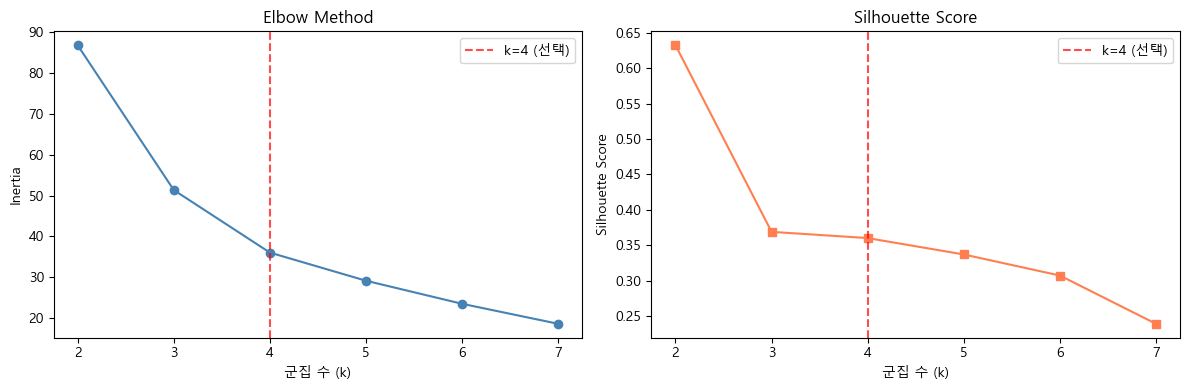

k별 Silhouette:
  k=2: 0.6328  ← Silhouette 최적
  k=3: 0.3688  
  k=4: 0.3600  
  k=5: 0.3369  
  k=6: 0.3071  
  k=7: 0.2388  

[k=4 선택 근거]
  - 표본이 25개(자치구)로 적어 Silhouette이 k=2에서 높게 나오는 경향이 있음
  - 2분할은 정보량이 부족하여 도시 구조 설명에 한계
  - 4분할(주거형/상업·업무형/유동인구형/혼합형)이 정책 해석에 가장 실용적
  - Silhouette은 참고 지표, 최종 판단은 군집 내용의 해석 가능성 우선


In [6]:
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('군집 수 (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4 (선택)')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 's-', color='coral')
axes[1].set_xlabel('군집 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4 (선택)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print('k별 Silhouette:')
for k, s in zip(K_range, silhouettes):
    mark = '← Silhouette 최적' if k == best_k else ''
    print(f'  k={k}: {s:.4f}  {mark}')

print()
print('[k=4 선택 근거]')
print('  - 표본이 25개(자치구)로 적어 Silhouette이 k=2에서 높게 나오는 경향이 있음')
print('  - 2분할은 정보량이 부족하여 도시 구조 설명에 한계')
print('  - 4분할(주거형/상업·업무형/유동인구형/혼합형)이 정책 해석에 가장 실용적')
print('  - Silhouette은 참고 지표, 최종 판단은 군집 내용의 해석 가능성 우선')

## 4. K-means 클러스터링 (k=4)

In [7]:
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=100)
f['cluster'] = km_final.fit_predict(X_scaled)

print('군집별 자치구:')
for c in range(K):
    gus = f[f['cluster'] == c]['gu'].tolist()
    print(f'  Cluster {c} ({len(gus)}개): {gus}')

군집별 자치구:
  Cluster 0 (3개): ['강북구', '도봉구', '중랑구']
  Cluster 1 (13개): ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
  Cluster 2 (2개): ['종로구', '중구']
  Cluster 3 (7개): ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']


## 5. 군집 특성 분석 — 라벨링 근거

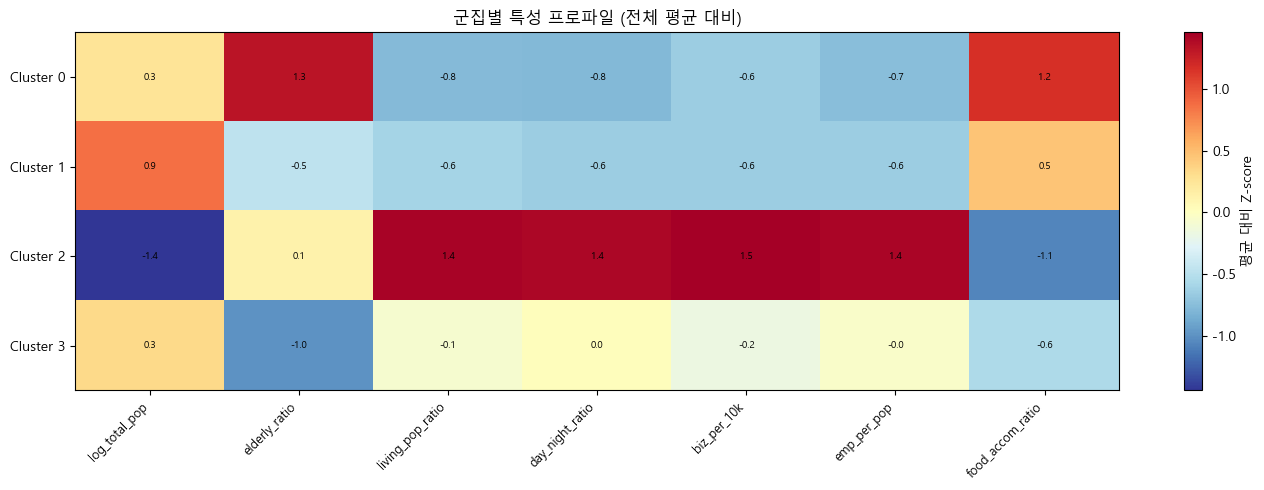


군집별 핵심 지표 (원값):
         log_total_pop  elderly_ratio  day_night_ratio  biz_per_10k  \
cluster                                                               
0              12.6993        22.1854           0.8876     927.2501   
1              13.0031        18.0457           0.9375     928.7069   
2              11.8552        19.3927           1.7023    4110.7136   
3              12.7374        16.8217           1.1884    1661.6939   

         food_accom_ratio  
cluster                    
0                  0.1697  
1                  0.1273  
2                  0.0377  
3                  0.0676  


In [8]:
# 군집별 변수 평균 (표준화 전 원값)
cluster_profile = f.groupby('cluster')[CLUSTER_VARS].mean()

# 전체 평균 대비 z-score로 표현
cluster_z = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(cluster_z.values, aspect='auto', cmap='RdYlBu_r')
plt.colorbar(im, ax=ax, label='평균 대비 Z-score')

ax.set_xticks(range(len(CLUSTER_VARS)))
ax.set_xticklabels(CLUSTER_VARS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Cluster {i}' for i in range(K)])
ax.set_title('군집별 특성 프로파일 (전체 평균 대비)')

for i in range(K):
    for j in range(len(CLUSTER_VARS)):
        ax.text(j, i, f'{cluster_z.values[i,j]:.1f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUT / 'cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n군집별 핵심 지표 (원값):')
display_cols = ['log_total_pop', 'elderly_ratio', 'day_night_ratio', 'biz_per_10k', 'food_accom_ratio']
print(cluster_profile[display_cols].round(4))

In [9]:
for c in range(K):
    sub = f[f['cluster'] == c].set_index('gu')
    print(f'\n── Cluster {c} ({len(sub)}개 구) ──')
    print('  구:', sub.index.tolist())
    print('  log(인구)    :', sub['log_total_pop'].mean().round(3))
    print('  고령인구비율 :', sub['elderly_ratio'].mean().round(2))
    print('  생활인구비율 :', sub['living_pop_ratio'].mean().round(3))
    print('  주야간인구비 :', sub['day_night_ratio'].mean().round(3))
    print('  만명당사업체 :', sub['biz_per_10k'].mean().round(1))
    print('  종사자/인구  :', sub['emp_per_pop'].mean().round(3))
    print('  음식숙박비중 :', sub['food_accom_ratio'].mean().round(3))


── Cluster 0 (3개 구) ──
  구: ['강북구', '도봉구', '중랑구']
  log(인구)    : 12.699
  고령인구비율 : 22.19
  생활인구비율 : 21.378
  주야간인구비 : 0.888
  만명당사업체 : 927.3
  종사자/인구  : 0.272
  음식숙박비중 : 0.17

── Cluster 1 (13개 구) ──
  구: ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
  log(인구)    : 13.003
  고령인구비율 : 18.05
  생활인구비율 : 23.345
  주야간인구비 : 0.938
  만명당사업체 : 928.7
  종사자/인구  : 0.371
  음식숙박비중 : 0.127

── Cluster 2 (2개 구) ──
  구: ['종로구', '중구']
  log(인구)    : 11.855
  고령인구비율 : 19.39
  생활인구비율 : 46.353
  주야간인구비 : 1.702
  만명당사업체 : 4110.7
  종사자/인구  : 2.489
  음식숙박비중 : 0.038

── Cluster 3 (7개 구) ──
  구: ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']
  log(인구)    : 12.737
  고령인구비율 : 16.82
  생활인구비율 : 29.278
  주야간인구비 : 1.188
  만명당사업체 : 1661.7
  종사자/인구  : 0.989
  음식숙박비중 : 0.068


## 6. 군집 라벨링

아래 결과를 보고 각 군집에 라벨을 붙인다.
- **주거형**: 인구밀도 높음, 직장인구 비율 낮음, 고령화율 높음
- **상업·업무형**: 직장인구 비율 높음, 사업체 밀도 높음, 매출 높음
- **유동인구형**: 직장인구/주민 비율 높음, 음식숙박 비중 높음
- **혼합형**: 여러 특성이 중간값 수준

In [10]:
# ── 축별 군집 점수 계산 ─────────────────────────────────
axis_scores = {
    '주거형':      cluster_z[['log_total_pop', 'elderly_ratio']].mean(axis=1),
    '상업·업무형': cluster_z[['biz_per_10k', 'emp_per_pop']].mean(axis=1),
    '고령·생활상권형':  cluster_z[['living_pop_ratio', 'day_night_ratio', 'food_accom_ratio']].mean(axis=1),
    '혼합형':      cluster_z[CLUSTER_VARS].abs().mean(axis=1) * -1,  # 평균으로부터 가장 가까운 군집
}
axis_df = pd.DataFrame(axis_scores)
print('축별 군집 점수 (클수록 해당 성격이 강함):')
print(axis_df.round(2))

# ── 1:1 그리디 배정 (중복 라벨 방지) ─────────────────────
LABEL_PRIORITY = ['상업·업무형', '고령·생활상권형', '주거형', '혼합형']
auto_labels = {}
assigned_clusters = set()

for label in LABEL_PRIORITY:
    candidates = axis_df[label].drop(list(assigned_clusters))
    if candidates.empty:
        break
    best_cluster = candidates.idxmax()
    auto_labels[best_cluster] = label
    assigned_clusters.add(best_cluster)

for c in range(K):
    if c not in auto_labels:
        auto_labels[c] = '혼합형'

print('\n자동 라벨링 결과 (1:1 배정):')
for c in range(K):
    gus = f[f['cluster'] == c]['gu'].tolist()
    print(f'  Cluster {c} → {auto_labels[c]}: {gus}')

LABEL_MAP = {}
print('\n(LABEL_MAP이 비어 있으면 자동 배정 사용)')

축별 군집 점수 (클수록 해당 성격이 강함):
          주거형  상업·업무형  고령·생활상권형   혼합형
cluster                              
0        0.79   -0.70     -0.13 -0.81
1        0.20   -0.65     -0.26 -0.62
2       -0.66    1.44      0.59 -1.19
3       -0.33   -0.10     -0.20 -0.31

자동 라벨링 결과 (1:1 배정):
  Cluster 0 → 고령·생활상권형: ['강북구', '도봉구', '중랑구']
  Cluster 1 → 주거형: ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
  Cluster 2 → 상업·업무형: ['종로구', '중구']
  Cluster 3 → 혼합형: ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']

(LABEL_MAP이 비어 있으면 자동 배정 사용)


In [11]:
# LABEL_MAP이 비어있으면 자동 추정값 사용
if not LABEL_MAP:
    LABEL_MAP = auto_labels

f['gu_type'] = f['cluster'].map(LABEL_MAP)

# 유형별 최종 자치구 목록
type_order = ['주거형','상업·업무형','고령·생활상권형','물류·혼합형','혼합형']
for t in type_order:
    gus = f[f['gu_type'] == t]['gu'].tolist()
    if gus:
        print(f'{t} ({len(gus)}): {gus}')

주거형 (13): ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
상업·업무형 (2): ['종로구', '중구']
고령·생활상권형 (3): ['강북구', '도봉구', '중랑구']
혼합형 (7): ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']


## 7. PCA 2D 시각화

PC1 설명 분산: 70.3%
PC2 설명 분산: 19.8%


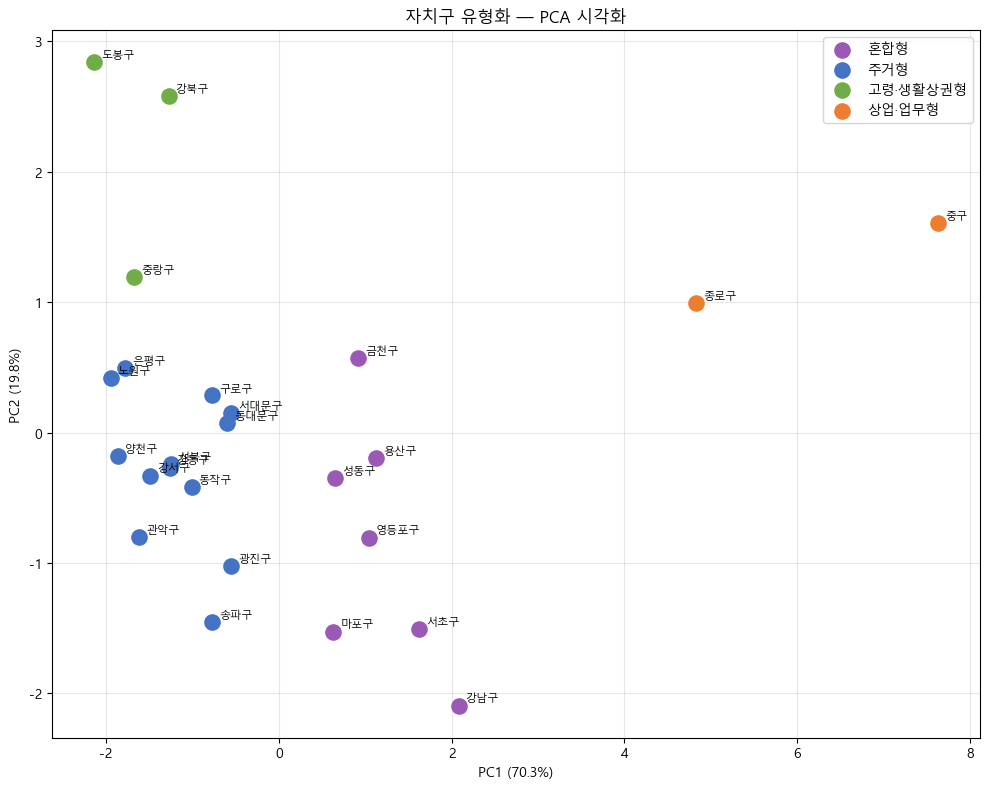

In [12]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

print(f'PC1 설명 분산: {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 설명 분산: {pca.explained_variance_ratio_[1]:.1%}')

COLORS = {'주거형':'#4472C4','상업·업무형':'#ED7D31','고령·생활상권형':'#70AD47','물류·혼합형':'#FFC000','혼합형':'#9B59B6'}

fig, ax = plt.subplots(figsize=(10, 8))
for t in f['gu_type'].unique():
    mask = f['gu_type'] == t
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=COLORS.get(t, 'gray'), s=120, label=t, zorder=3)

for i, gu in enumerate(X_scaled.index):
    ax.annotate(gu, (coords[i, 0], coords[i, 1]),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('자치구 유형화 — PCA 시각화')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 레이더 차트 — 유형별 특성 프로파일

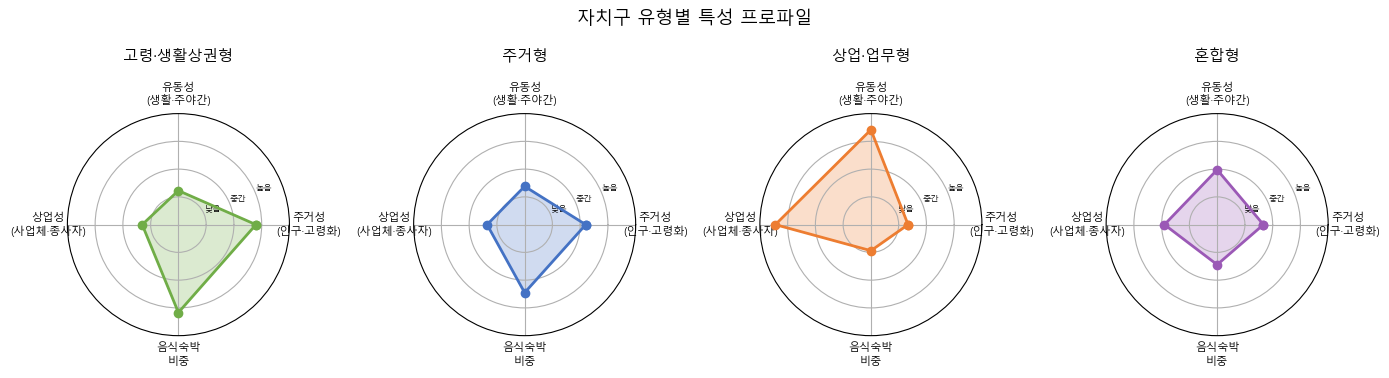

In [13]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

# 축 4개
AXES = ['주거성\n(인구·고령화)', '유동성\n(생활·주야간)', '상업성\n(사업체·종사자)', '음식숙박\n비중']
AXIS_COLS = [
    ['log_total_pop', 'elderly_ratio'],
    ['living_pop_ratio', 'day_night_ratio'],
    ['biz_per_10k', 'emp_per_pop'],
    ['food_accom_ratio'],
]

# 군집별 각 축 평균 z-score
radar_data = {}
for i, cols in enumerate(AXIS_COLS):
    radar_data[AXES[i]] = cluster_z[cols].mean(axis=1)
radar_df = pd.DataFrame(radar_data)
radar_df.index = [LABEL_MAP.get(i, f'C{i}') for i in radar_df.index]

# 레이더 차트
n_axes = len(AXES)
angles = [2 * np.pi * i / n_axes for i in range(n_axes)]
angles += angles[:1]

fig, axes = plt.subplots(1, len(radar_df), figsize=(14, 3.5),
                          subplot_kw=dict(polar=True))
if len(radar_df) == 1:
    axes = [axes]

for ax, (label, row) in zip(axes, radar_df.iterrows()):
    vals = (row.values + 2) / 4
    vals = np.clip(vals, 0, 1)
    vals = np.append(vals, vals[0])

    color = list(COLORS.values())[list(COLORS.keys()).index(label) if label in COLORS else 0]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color)
    ax.fill(angles, vals, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(AXES, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['낮음', '중간', '높음'], fontsize=6)
    ax.set_title(label, fontsize=11, pad=15)

plt.suptitle('자치구 유형별 특성 프로파일', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 결과 저장

In [14]:
# 클러스터링 결과 저장
result_cols = ['gu', 'cluster', 'gu_type'] + CLUSTER_VARS
df_result = f[result_cols].sort_values('cluster').reset_index(drop=True)
df_result.to_csv(OUT / 'gu_cluster_result.csv', index=False, encoding='utf-8-sig')
print('저장:', df_result.shape)

# 군집 특성 프로파일 저장
profile_out = cluster_profile.copy()
profile_out.index = [LABEL_MAP.get(i, f'C{i}') for i in profile_out.index]
profile_out.to_csv(OUT / 'gu_cluster_profile.csv', encoding='utf-8-sig')

print('\n── 최종 유형화 결과 ──')
for _, row in df_result[['gu', 'gu_type']].iterrows():
    print(f'  {row["gu"]:6s} → {row["gu_type"]}')

저장: (25, 10)

── 최종 유형화 결과 ──
  강북구    → 고령·생활상권형
  도봉구    → 고령·생활상권형
  중랑구    → 고령·생활상권형
  강서구    → 주거형
  구로구    → 주거형
  광진구    → 주거형
  노원구    → 주거형
  강동구    → 주거형
  서대문구   → 주거형
  동작구    → 주거형
  동대문구   → 주거형
  은평구    → 주거형
  송파구    → 주거형
  양천구    → 주거형
  성북구    → 주거형
  관악구    → 주거형
  종로구    → 상업·업무형
  중구     → 상업·업무형
  성동구    → 혼합형
  금천구    → 혼합형
  강남구    → 혼합형
  서초구    → 혼합형
  마포구    → 혼합형
  영등포구   → 혼합형
  용산구    → 혼합형


In [15]:
# 유형별 요약 통계
summary = df_result.groupby('gu_type')[CLUSTER_VARS].mean().round(4)
print('유형별 평균 특성값:')
summary

유형별 평균 특성값:


,log_total_pop,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio
gu_type,,,,,,,
고령·생활상권형,12.6993,22.1854,21.3781,0.8876,927.2501,0.2719,0.1697
상업·업무형,11.8552,19.3927,46.3532,1.7023,4110.7136,2.4892,0.0377
주거형,13.0031,18.0457,23.3448,0.9375,928.7069,0.3708,0.1273
혼합형,12.7374,16.8217,29.2781,1.1884,1661.6939,0.9891,0.0676
